# Step 1

**1.** **Yes**, put-call parity applies to European options because their fixed expiration prevents early exercise, enabling arbitrage-free pricing via the relation:
$$
C − P = S − PV(K).
$$

**2.** The put-call parity formula rearranged to solve for the call price is
$$
C = P + S − PV(K)
$$

where:

**C** = Call option price

**P** = Put option price

**S** = Spot price of the underlying asset

**PV(K)** = Present value of the strike price **K**, discounted at the risk-free rate.

**3.** The put-call parity formula rearranged to solve for the put price is
$$
P = C − S + PV(K)
$$
where:

**P** = Put option price

**C** = Call option price

**S** = Spot price of the underlying asset

**PV(K)** = Present value of the strike price K, discounted at the risk-free rate.

**4.** **No**, put-call parity does not strictly apply to American options due to early exercise rights, leading to inequalities instead of an exact relationship:
$$
S −K ≤ C − P ≤ S − PV(K).
$$ Early exercise disrupts replication and arbitrage enforcement.


**5.** **a.** We choose to use 100 steps for good accuracy.
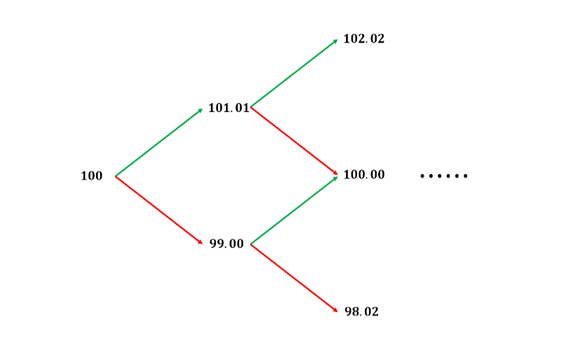



In [1]:
import numpy as np
import pandas as pd

In [2]:
import numpy as np

# Parameters
S0 = 100         # Initial stock price
K = 100          # Strike price (ATM)
r = 0.05         # Annual risk-free rate
sigma = 0.20     # Annual volatility
T = 0.25         # Time to maturity in years (3 months)
N = 100          # Number of steps in the binomial tree

# Time step
dt = T / N
u = np.exp(sigma * np.sqrt(dt))    # Up factor
d = 1 / u                          # Down factor
p = (np.exp(r * dt) - d) / (u - d) # Risk-neutral probability
discount = np.exp(-r * dt)         # Discount factor

# Create asset prices at maturity
ST = np.array([S0 * (u ** j) * (d ** (N - j)) for j in range(N + 1)])

# Option payoffs at maturity
call_values = np.maximum(ST - K, 0)
put_values = np.maximum(K - ST, 0)

# Backward induction
for i in range(N - 1, -1, -1):
    call_values = discount * (p * call_values[1:] + (1 - p) * call_values[:-1])
    put_values = discount * (p * put_values[1:] + (1 - p) * put_values[:-1])

# Output results
print(f"European Call Price (ATM): {call_values[0]:.2f}")
print(f"European Put Price (ATM): {put_values[0]:.2f}")

European Call Price (ATM): 4.61
European Put Price (ATM): 3.36


In [3]:
import numpy as np

def european_option(S_0, K, T, r, sigma, N, opttype):
    dt = T / N  # Time step
    u = np.exp(sigma * np.sqrt(dt))  # Up factor
    d = 1 / u  # Down factor
    p = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability

    C = np.zeros([N + 1, N + 1])  # Option price matrix
    S = np.zeros([N + 1, N + 1])  # Stock price matrix
    Delta = np.zeros([N, N])      # Delta matrix

    # Terminal payoff at maturity
    for i in range(N + 1):
        S[N, i] = S_0 * (u ** i) * (d ** (N - i))
        if opttype == "C":
            C[N, i] = max(S[N, i] - K, 0)
        else:
            C[N, i] = max(K - S[N, i], 0)

    # Backward induction without early exercise
    for j in range(N - 1, -1, -1):
        for i in range(j + 1):
            S[j, i] = S_0 * (u ** i) * (d ** (j - i))
            C[j, i] = np.exp(-r * dt) * (p * C[j + 1, i + 1] + (1 - p) * C[j + 1, i])
            Delta[j, i] = (C[j + 1, i + 1] - C[j + 1, i]) / (S[j + 1, i + 1] - S[j + 1, i])

    return C[0, 0], C, S, Delta, p, u, d

In [4]:
C_at_00, C_matrix, S_matrix, C_Delta, p, u, d = european_option(100, 100, 0.25, 0.05, 0.2, 100, "C")

Asset price movemnet is calculated using $S(n,i)=S_0×u^i×d^(n-1)$
$S(n, i)$ represents the asset price at time step $n$ after $i$ upward movements.

* $n$ corresponds to row number, indicating the number of time steps.
* $i$ corresponds to column number, representing the number of upward movements at that step.

$$S(n, i) = S_0 \times u^i \times d^{n-i}$$

$S(1,1)$: Asset price after 1 time step and 1 upward movement.

$S(1,1) = 100 \times 1.011 \times 0.991^{-1} = 100 \times 1.01 = 101.1$

At the time of expiration for a European option, the value is:

* for a call option, $\max(S - K, 0)$
* for a put option, $\max(K - S, 0)$

The value of the option at each node is computed by:

$f = e^{-r\Delta t}(pC_u + (1 - p)C_d)$$

Where:

* $C_u$= Option value at the up node in the next time step
* $C_d$= Option value at the down node in the next time step

European options can only be exercised at maturity, we do not consider early exercise. Therefore, the option value is always the expected discounted value, and we do not compare it to intrinsic value at each step.

The valuation starts at the final nodes of the binomial tree where the intrinsic value is calculated and proceeds backward step by step by using the risk-neutral expected value until we reach the initial node.

Table 2 shows the European call option values for the first seven steps of a 100-step binomial tree. The value at $C(0,0)$ represents the call option price at the initial time, which is $\$4.61$.

In [5]:
# Convert to DataFrame for display
S_dtaf = pd.DataFrame(S_matrix).round(2)
S_dtaf

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,99.00,101.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,98.02,100.00,102.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,97.04,99.00,101.01,103.05,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,96.08,98.02,100.00,102.02,104.08,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,38.29,39.06,39.85,40.66,41.48,42.32,43.17,44.04,44.93,45.84,...,236.32,241.09,245.96,250.93,256.00,261.17,0.00,0.00,0.00,0.00
97,37.91,38.67,39.46,40.25,41.07,41.90,42.74,43.60,44.49,45.38,...,233.96,238.69,243.51,248.43,253.45,258.57,263.79,0.00,0.00,0.00
98,37.53,38.29,39.06,39.85,40.66,41.48,42.32,43.17,44.04,44.93,...,231.64,236.32,241.09,245.96,250.93,256.00,261.17,266.45,0.00,0.00
99,37.16,37.91,38.67,39.46,40.25,41.07,41.90,42.74,43.60,44.49,...,229.33,233.96,238.69,243.51,248.43,253.45,258.57,263.79,269.12,0.00


In [6]:
# First seven steps
S_dtaf.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,99.00,101.01,0.00,0.00,0.00,0.00,0.00,0.00
2,98.02,100.00,102.02,0.00,0.00,0.00,0.00,0.00
3,97.04,99.00,101.01,103.05,0.00,0.00,0.00,0.00
4,96.08,98.02,100.00,102.02,104.08,0.00,0.00,0.00
5,95.12,97.04,99.00,101.01,103.05,105.13,0.00,0.00
6,94.18,96.08,98.02,100.00,102.02,104.08,106.18,0.00
7,93.24,95.12,97.04,99.00,101.01,103.05,105.13,107.25


In [7]:
# Convert to DataFrame for display
C_dtaf = pd.DataFrame(C_matrix).round(2)
C_dtaf

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,4.61,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,4.03,5.17,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,3.50,4.55,5.78,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,3.02,3.98,5.12,6.44,0.00,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,2.59,3.45,4.50,5.73,7.14,0.0,0.0,0.0,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,136.37,141.14,146.01,150.98,156.05,161.22,0.00,0.00,0.00,0.00
97,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,134.00,138.73,143.55,148.47,153.49,158.61,163.83,0.00,0.00,0.00
98,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,131.66,136.34,141.11,145.99,150.95,156.02,161.19,166.47,0.00,0.00
99,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,129.34,133.98,138.70,143.53,148.44,153.46,158.58,163.81,169.14,0.00


In [8]:
# First seven steps
C_dtaf.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,4.61,0.00,0.00,0.00,0.00,0.00,0.00,0.0
1,4.03,5.17,0.00,0.00,0.00,0.00,0.00,0.0
2,3.50,4.55,5.78,0.00,0.00,0.00,0.00,0.0
3,3.02,3.98,5.12,6.44,0.00,0.00,0.00,0.0
4,2.59,3.45,4.50,5.73,7.14,0.00,0.00,0.0
5,2.19,2.97,3.93,5.06,6.38,7.88,0.00,0.0
6,1.85,2.54,3.40,4.45,5.67,7.08,8.67,0.0
7,1.54,2.15,2.92,3.87,5.01,6.33,7.83,9.5


In [9]:
C_at_00, Cp_matrix, Sp_matrix, P_Delta, p, u, d = european_option(100, 100, 0.25, 0.05, 0.2, 100, "P")

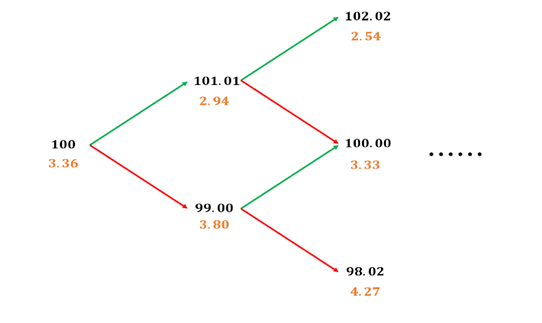

In [10]:
# Convert to DataFrame and display
P_dtaf = pd.DataFrame(Cp_matrix).round(2)
P_dtaf

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,3.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.80,2.94,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.27,3.33,2.54,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.77,3.77,2.91,2.19,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.32,4.24,3.31,2.51,1.86,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,61.66,60.89,60.10,59.29,58.47,57.63,56.78,55.91,55.02,54.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,62.05,61.29,60.51,59.71,58.90,58.07,57.22,56.36,55.48,54.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,62.44,61.69,60.91,60.12,59.32,58.50,57.66,56.80,55.93,55.04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99,62.83,62.08,61.31,60.53,59.74,58.92,58.09,57.25,56.38,55.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# First seven steps
P_dtaf.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,3.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,3.80,2.94,0.00,0.00,0.00,0.00,0.00,0.00
2,4.27,3.33,2.54,0.00,0.00,0.00,0.00,0.00
3,4.77,3.77,2.91,2.19,0.00,0.00,0.00,0.00
4,5.32,4.24,3.31,2.51,1.86,0.00,0.00,0.00
5,5.89,4.75,3.74,2.88,2.16,1.57,0.00,0.00
6,6.50,5.29,4.21,3.28,2.49,1.83,1.32,0.00
7,7.14,5.87,4.72,3.71,2.85,2.13,1.55,1.09


**b.** In order to price an at the money European call and put, we use a binomial tree which represents possible stock price moves over 100 time steps. In each step, the price can go up or down according to the volatility and using the risk free rate we compute the risk neutral probabilities. We begin by computing the payoff of the option at maturity and work backward, discounting the expected values to the present.

Choosing 100 steps provides a good balance between computational efficiency and pricing accuracy, closely approximating the results from continuous-time models like Black-Scholes.



6. **a.** Delta $\Delta$ is the rate of change of the option value with respect to the underlying asset price $S$.
In a binomial model, Delta at each node is calculated as:

$$\Delta = \frac{C_u - C_d}{S_u - S_d}$$

Let's calculate for node (0,0):

* Delta for Call option

$$\Delta_{call} = \frac{5.17 - 4.03}{101 - 99} \approx 0.57$$

##### Call Delta valbes at each node

In [12]:
C_Delta_df = pd.DataFrame(C_Delta).round(2)
C_Delta_df.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,0.57,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.53,0.61,0.00,0.00,0.00,0.00,0.00,0.00
2,0.49,0.57,0.65,0.00,0.00,0.00,0.00,0.00
3,0.45,0.53,0.61,0.68,0.00,0.00,0.00,0.00
4,0.41,0.49,0.57,0.65,0.72,0.00,0.00,0.00
5,0.36,0.44,0.53,0.61,0.68,0.75,0.00,0.00
6,0.33,0.40,0.48,0.57,0.65,0.72,0.79,0.00
7,0.29,0.36,0.44,0.53,0.61,0.68,0.75,0.82


##### Put Delta valbes at each node

In [13]:
P_Delta_df = pd.DataFrame(P_Delta).round(2)
P_Delta_df.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,-0.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,-0.47,-0.39,0.00,0.00,0.00,0.00,0.00,0.00
2,-0.51,-0.43,-0.35,0.00,0.00,0.00,0.00,0.00
3,-0.55,-0.47,-0.39,-0.32,0.00,0.00,0.00,0.00
4,-0.59,-0.51,-0.43,-0.35,-0.28,0.00,0.00,0.00
5,-0.64,-0.56,-0.47,-0.39,-0.32,-0.25,0.00,0.00
6,-0.67,-0.60,-0.52,-0.43,-0.35,-0.28,-0.21,0.00
7,-0.71,-0.64,-0.56,-0.47,-0.39,-0.32,-0.25,-0.18


Call Delta is positive (+0.57), while Put Delta is negative (-0.43) when ATM. They are approximately symmetric in magnitude but opposite in sign.

| European Call Delta | 0.57 |
|---|---|
| European Put Delta | -0.43 |



**b.** European calls show positive Delta values and European puts indicate negative Delta values. An increase in Delta on a Call indicates a positive delta, the call has value to it as the stock rises in value, needing to take a long position in shares to hedge, just the opposite would be true for a negative delta on a Put, meaning the Put loses value with respect to an increase in value in the stock, requiring a short position in shares. Rather, the higher size of the call’s implied volatility is based on its limitless upside potential that keeps sensitivity of the net profit within feasible bounds, but the put does not. Consistency with arbitrage free pricing and put call parity are confirmed by theoretical consistency of **ΔCall − ΔPut =1**.


7 **a.** Vega measures the sensitivity of the option's price to changes in the volatility of the underlying asset.

$$Vega = \frac{\partial V}{\partial \sigma}$$

Where:

* $V$ = value of the option
* $\sigma$ = volatility of the underlying asset

To compute Vega, we will use the finite difference method (numerical approximation), which works like this:

$$Vega \approx \frac{V(\sigma_2) - V(\sigma_1)}{\sigma_2 - \sigma_1}$$

Where:

* $V(\sigma_2)$ and $V(\sigma_1)$ are option prices at volatilities $\sigma_1$ and $\sigma_2$
* $\sigma_1 = 0.20$, $\sigma_2 = 0.25$

- Vega for Call option

$$Vega_{call} = \frac{5.59 - 4.61}{0.25 - 0.20} = 19.62$$

- Vega for put option

$$Vega_{put} = \frac{4.34 - 3.36}{0.25 - 0.20} = 19.62$$

Both call and put prices increase with higher volatility. Vega is positive for both options.


| Call Price at 20% | 4.61 |
|---|---|
| Call Price at 25% | 5.59 |




In [14]:
import numpy as np

# Function to compute European call and put using binomial tree
def binomial_option_price(S0, K, r, sigma, T, N=100):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    ST = np.array([S0 * (u ** j) * (d ** (N - j)) for j in range(N + 1)])
    call = np.maximum(ST - K, 0)
    put = np.maximum(K - ST, 0)

    # Backward induction
    for i in range(N - 1, -1, -1):
        call = discount * (p * call[1:] + (1 - p) * call[:-1])
        put = discount * (p * put[1:] + (1 - p) * put[:-1])

    return call[0], put[0]

# Parameters
S0 = 100
K = 100
r = 0.05
T = 0.25
N = 100

# Prices at 20% volatility
call_20, put_20 = binomial_option_price(S0, K, r, 0.20, T, N)

# Prices at 25% volatility
call_25, put_25 = binomial_option_price(S0, K, r, 0.25, T, N)

# Vega approximation
vega_call = (call_25 - call_20) / 0.05
vega_put = (put_25 - put_20) / 0.05

print(f"Call Price at 20% vol: {call_20:.2f}, at 25% vol: {call_25:.2f}, Vega: {vega_call:.2f}")
print(f"Put Price at 20% vol: {put_20:.2f}, at 25% vol: {put_25:.2f}, Vega: {vega_put:.2f}")

Call Price at 20% vol: 4.61, at 25% vol: 5.59, Vega: 19.62
Put Price at 20% vol: 3.36, at 25% vol: 4.34, Vega: 19.62


**b.** Rising volatility increases the value of both calls and puts, but the effect is potentially different with different option characteristics. Because both options were at-the-money, with short maturity, the effect was almost exactly the same. But for options that are distant in or out of the money or close to their expiry date, Vega could be significantly different, more so for one kind of option than the other.

**8.**
Given an initial option price of $S_0 = \$100$, a risk-free interest rate of $r = 5\%$, volatility $\sigma = 20\%$, and a maturity of $T = 3$ months, we consider an at-the-money (ATM) American call and put option, meaning the strike price $K = \$100$ matches the initial price.

a) To model this option using a binomial tree, we select $N = 100$ steps. Since American options allow early exercise at any point before expiration, a higher number of steps provides greater flexibility in determining the optimal exercise moments. In this setup, 100 steps are chosen to simplify computations, making the numerical process more straightforward while maintaining accuracy in the valuation.

b) Cox, Ross, and Rubinstein [1] used below formula to calculate the upward$(u)$ and downward$(d)$ movements to match the volatility:

$u = e^{\sigma \sqrt{\Delta t}}$
$d = e^{-\sigma \sqrt{\Delta t}} = \frac{1}{u}$

Here, $\Delta t$ is the length of the time step.

$\Delta t = \frac{T}{N} = \left(\frac{3}{12}\right)\frac{1}{100} = \frac{0.25}{100} = 0.0025$

So, upward movement:

$u = e^{\sigma \sqrt{\Delta t}} = e^{0.2 \times \sqrt{0.0025}} = e^{0.2 \times 0.05} = e^{0.01} \approx 1.01$

Downward movement:

$d = e^{-\sigma \sqrt{\Delta t}} = \frac{1}{e^{0.01}} \approx 0.99$

Risk neutral probability is calculated using:

$p = \frac{e^{rT} - d}{u - d} = \frac{e^{0.05 \times 0.25} - 0.99}{1.01 - 0.99}$

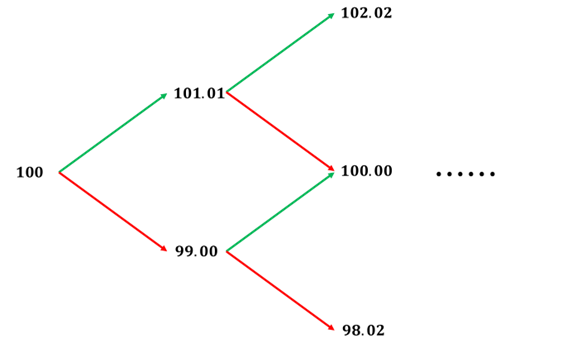

In [15]:
def american_option(S_ini, K, T, r, sigma, N, opttype):
    dt = T / N  # Define time step
    u = np.exp(sigma * np.sqrt(dt))  # Up factor
    d = 1 / u  # Down factor
    p = (np.exp(r * dt) - d) / (u - d)  # risk neutral probs

    C = np.zeros([N + 1, N + 1])  # call prices
    S = np.zeros([N + 1, N + 1])  # underlying price
    Delta = np.zeros([N, N])  # delta

    for i in range(0, N + 1):
        S[N, i] = S_ini * (u ** (i)) * (d ** (N - i))
        if opttype == "C":
            C[N, i] = max(S[N, i] - K, 0)
        else:
            C[N, i] = max(K - S[N, i], 0)

    for j in range(N - 1, -1, -1):
        for i in range(0, j + 1):
            C[j, i] = np.exp(-r * dt) * (
                p * C[j + 1, i + 1] + (1 - p) * C[j + 1, i]
            )  # Computing the European option prices
            S[j, i] = (
                S_ini * (u ** (i)) * (d ** (j - i))
            )  # Underlying evolution for each node
            if opttype == "C":
                C[j, i] = max(
                    C[j, i], S[j, i] - K
                )
            else:
                C[j, i] = max(
                    C[j, i], K - S[j, i]
                )

            Delta[j, i] = (C[j + 1, i + 1] - C[j + 1, i]) / (
                S[j + 1, i + 1] - S[j + 1, i]
            )  # Computing the delta for each node

    return C[0, 0], C, S, Delta, p,u,d

In [16]:
C_at_00, C_matrix, S_matrix, Delta, p, u, d = american_option(100, 100, 0.25, 0.05, 0.2, 100, "C")

In [17]:
C_at_00.round(2)

np.float64(4.61)

In [18]:
S_df = pd.DataFrame(S_matrix).round(2)
S_df

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,99.00,101.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,98.02,100.00,102.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,97.04,99.00,101.01,103.05,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,96.08,98.02,100.00,102.02,104.08,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,38.29,39.06,39.85,40.66,41.48,42.32,43.17,44.04,44.93,45.84,...,236.32,241.09,245.96,250.93,256.00,261.17,0.00,0.00,0.00,0.00
97,37.91,38.67,39.46,40.25,41.07,41.90,42.74,43.60,44.49,45.38,...,233.96,238.69,243.51,248.43,253.45,258.57,263.79,0.00,0.00,0.00
98,37.53,38.29,39.06,39.85,40.66,41.48,42.32,43.17,44.04,44.93,...,231.64,236.32,241.09,245.96,250.93,256.00,261.17,266.45,0.00,0.00
99,37.16,37.91,38.67,39.46,40.25,41.07,41.90,42.74,43.60,44.49,...,229.33,233.96,238.69,243.51,248.43,253.45,258.57,263.79,269.12,0.00


In [19]:
S_df.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,99.00,101.01,0.00,0.00,0.00,0.00,0.00,0.00
2,98.02,100.00,102.02,0.00,0.00,0.00,0.00,0.00
3,97.04,99.00,101.01,103.05,0.00,0.00,0.00,0.00
4,96.08,98.02,100.00,102.02,104.08,0.00,0.00,0.00
5,95.12,97.04,99.00,101.01,103.05,105.13,0.00,0.00
6,94.18,96.08,98.02,100.00,102.02,104.08,106.18,0.00
7,93.24,95.12,97.04,99.00,101.01,103.05,105.13,107.25


Since, American options exercise at any time before expiration. We need to consider both:

* The value of option if held till the next step $f = e^{-r\Delta t}(pC_u + (1-p)C_d)$
* The value of option if exercised early, i.e., intrinsic value $max\{0, S_T - K\}$ (or $max\{0, K - S_T\}$)

Therefore, the value of option at earlier node is $max\{f = e^{-r\Delta t}(pC_u + (1-p)C_d), intrinsic \ value\}$.
Option valuation begins at the final (terminal) nodes of the binomial tree and proceeds backward step by step toward the initial node. The value at C(0,0) represents the call option price at the initial time, which is $4.61.

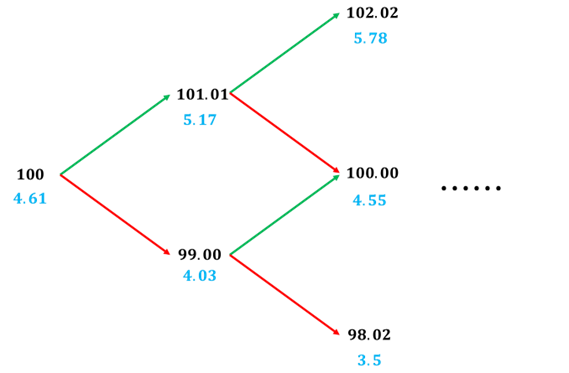

In [20]:
C_df = pd.DataFrame(C_matrix)
C_df

,0,1,2,3,4,5,6,7,8,9,...,91,92,93,94,95,96,97,98,99,100
0,4.605026,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4.032032,5.170631,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3.504864,4.552352,5.780987,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3.023379,3.980050,5.117263,6.436263,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2.587017,3.453993,4.499262,5.727331,7.136236,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,136.366057,141.139958,146.010299,150.979026,156.048129,161.219635,0.000000,0.000000,0.000000,0.000000
97,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,134.002178,138.728578,143.550458,148.469746,153.488411,158.608459,163.831939,0.000000,0.000000,0.000000
98,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,131.661695,136.341066,141.114968,145.985308,150.954036,156.023139,161.194644,166.470621,0.000000,0.000000
99,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,129.344373,133.977184,138.703585,143.525464,148.444753,153.463417,158.583465,163.806945,169.135946,0.000000


In [21]:
C_df_rounded = C_df.round(2)
C_df_rounded
C_df_rounded.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,4.61,0.00,0.00,0.00,0.00,0.00,0.00,0.0
1,4.03,5.17,0.00,0.00,0.00,0.00,0.00,0.0
2,3.50,4.55,5.78,0.00,0.00,0.00,0.00,0.0
3,3.02,3.98,5.12,6.44,0.00,0.00,0.00,0.0
4,2.59,3.45,4.50,5.73,7.14,0.00,0.00,0.0
5,2.19,2.97,3.93,5.06,6.38,7.88,0.00,0.0
6,1.85,2.54,3.40,4.45,5.67,7.08,8.67,0.0
7,1.54,2.15,2.92,3.87,5.01,6.33,7.83,9.5


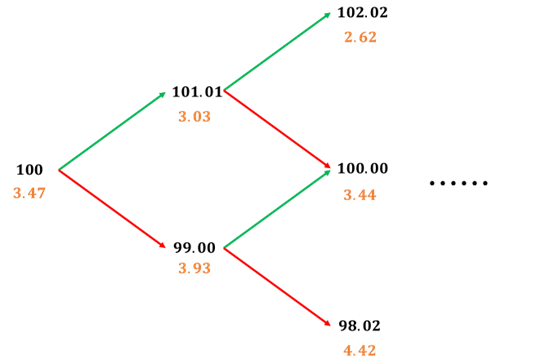

Table below presents American put option values for the first seven steps of a 100-step binomial tree. The price of the put option at node (0,0), representing the initial valuation, is 3.47.
It is important to note that at node (2,2), the asset price is 102.02, which is higher than the strike price of 100. Despite this, the put option retains a positive value of 2.62. This value does not arise from immediate exercise, since the option is out of the money, but rather from the potential for the asset price to fall in future steps, demonstrating the time value and flexibility associated with American options.

In [23]:
C_p_at_00_p, C_p_matrix, S_p_matrix, Delta_p, p, u, d = american_option(100, 100, 0.25, 0.05, 0.2, 100, "P")

In [24]:
C_p_df_rounded = pd.DataFrame(C_p_matrix).round(2)
C_p_df_rounded
C_p_df_rounded.iloc[:8, :8]

,0,1,2,3,4,5,6,7
0,3.47,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,3.93,3.03,0.00,0.00,0.00,0.00,0.00,0.00
2,4.42,3.44,2.62,0.00,0.00,0.00,0.00,0.00
3,4.95,3.90,3.00,2.25,0.00,0.00,0.00,0.00
4,5.52,4.39,3.41,2.59,1.91,0.00,0.00,0.00
5,6.13,4.92,3.87,2.97,2.22,1.61,0.00,0.00
6,6.78,5.50,4.36,3.38,2.56,1.88,1.35,0.00
7,7.46,6.11,4.90,3.84,2.93,2.19,1.59,1.12


**Question 9**

a) Delta of an option is the ratio of stock option's change in the price to the change in the price of underlying stock [2].

$$
\Delta = \frac{C_u - C_d}{S_u - S_d}
$$

**Call option**

Over the first-time step $C_u = 5.17$, $C_d = 4.03$ and asset movements $S_u = \$101.01$, $S_d = \$99.00$
Asset price movement over the first-time step ($\Delta$):

$$
\Delta = \frac{5.17 - 4.03}{101 - 99.00} \approx 0.57
$$

In [56]:
Delta

array([[-4.75556732e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-5.60805802e-01, -3.95110331e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
    

In [58]:


Delta_df = pd.DataFrame(Delta).round(2)
Delta_df


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,-0.48,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.56,-0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.65,-0.48,-0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.73,-0.57,-0.39,-0.24,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.81,-0.66,-0.48,-0.31,-0.18,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.88,-0.75,-0.57,-0.39,-0.24,-0.12,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.94,-0.83,-0.67,-0.49,-0.31,-0.17,-0.08,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,-0.98,-0.90,-0.76,-0.58,-0.39,-0.23,-0.11,-0.04,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,-1.00,-0.96,-0.84,-0.68,-0.49,-0.30,-0.16,-0.07,-0.02,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,-1.00,-0.99,-0.91,-0.78,-0.59,-0.39,-0.22,-0.10,-0.04,-0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Put option**

Over the first-time step $C_u = 3.03$, $C_d = 3.93$ and asset movements $S_u = \$101.01$, $S_d = \$99.00$
Asset price movement over the first-time step ($\Delta$):

$$
\Delta = \frac{3.03 - 3.93}{101 - 99.00} \approx -0.45
$$

| Call Delta | 0.57 |
|---|---|
| Put Delta | -0.45 |

Call Delta is positive (+0.57), while Put Delta is negative (–0.45) wh[  ] ATM.

b) The delta of a call option is positive, whereas the delta of a put option is negative. Delta indicates the number of units of the underlying asset that should be held for each option shorted in order to create a riskless (delta-neutral) portfolio.

In the case of the American put option considered, the delta is -0.45. This negative value indicates that the price of the option moves in the opposite direction to the movement of the asset price. A positive delta indicates that the option price and asset price move in the same direction.
A delta of -0.45 implies that 0.45 shares of the underlying asset must be purchased for each put option held in order to maintain a delta-neutral position.

In [61]:
Delta_p_df = pd.DataFrame(Delta_p).round(2)
Delta_p_df


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.45,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.49,-0.41,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.54,-0.45,-0.37,0.00,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.58,-0.49,-0.41,-0.33,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.62,-0.54,-0.45,-0.37,-0.29,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,-1.00,-1.00,-1.00,-1.00,-1.00,-1.0,-1.0,-1.0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**10**

a) **Sensitivity of option price to Volatility**

Table below lists the values of call and put options corresponding to different volatility levels. From the observed data, it is evident that as volatility increases from 20% to 25%, the prices of both call and put options also increase. This behavior reflects the fact that higher volatility leads to higher option premiums.

| Volatility | Call price |
|---|---|
| 20% | 4.61 |
| 25% | 5.59 |

| Volatility | Put price |
|---|---|
| 20% | 3.47 |
| 25% | 4.45 |


Vega ($v$) quantifies the sensitivity of an option's price to changes in volatility. It measures how much the option price changes in response to a change in the underlying asset's volatility.

$$
v = \frac{\text{Change in option price}}{\text{Change in Volatility}} = \frac{C_1 - C_2}{\sigma_1 - \sigma_2}
$$

Where $C_1$ is option price when volatility is $\sigma_1$ and $C_2$ is option price when volatility is $\sigma_2$.

**Vega for call option:**

$$
v = \frac{5.59 - 4.61}{25 - 20} = 0.196
$$

For every 1% change in volatility, call option price changes by $0.196

**Vega for put option:**

$$
v = \frac{4.45 - 3.47}{25 - 20} = 0.196
$$

For every 1% change in volatility, put option price changes by $0.196
b) Vega for both American call and put options is the same in many cases, indicating that both respond similarly to changes in volatility. However, this may not always hold true. The Vega can differ depending on factors such as time to expiration and the option’s moneyness.
For at-the-money (ATM) options, Vega is generally the same for both calls and puts. However, for deep in-the-money (DITM) options, Vega may differ due to the increased likelihood of early exercise—particularly for American puts—which reduces their sensitivity to volatility


In [62]:
volatility = [0.2, 0.25]
for vol in volatility:
  C_at_00, C, S_matrix, Delta, p, u, d = american_option(100, 100, 0.25, 0.05, vol, 100, "C")
  print(f"Call Price at {vol*100}% vol: {C_at_00:.2f}")

Call Price at 20.0% vol: 4.61
Call Price at 25.0% vol: 5.59


In [63]:
for vol in volatility:
  C_p_at_00_p, C_p_matrix, S_p_matrix, Delta_p, p, u, d = american_option(100, 100, 0.25, 0.05, vol, 100, "P")
  print(f"Put Price at {vol*100}% vol: {C_p_at_00_p:.2f}")

Put Price at 20.0% vol: 3.47
Put Price at 25.0% vol: 4.45


**11**

Given:

* $C = 4.61$ (European Call)
* $P = 3.36$ (European Put)
* $S_0 = 100$
* $K = 100$
* $r = 5\%$
* $T = 0.25$

Put-Call Parity:
$C - P = S_0 - Ke^{-rT}$

Calculate RHS:
$Ke^{-rT} = 100e^{-0.05(0.25)} = 100e^{-0.0125} \approx 98.76$
$S_0 - PV(K) = 100 - 98.76 = 1.24$

Calculate LHS:
$C - P = 4.61 - 3.36 = 1.25$

Result: $C - P \approx S_0 - PV(K)$, ($1.25 \approx 1.24$) within rounding error.

**12**

Given:

* American Call = $4.68$
* American Put = $3.47$

The Put-Call Parity relationship is not strictly maintained for American options due to the potential impact of their early exercise feature on pricing.

Check difference:
$C_{Am} - P_{Am} = 4.68 - 3.47 = 1.21$

Compare with European parity RHS:
$S_0 - PV(K) = 1.24$

**Observation:** While the result may be similar, there's no guarantee of parity due to the possibility of early exercise for American put options, which can disrupt the strict adherence to parity conditions.

**Conclusion:** Although parity isn't guaranteed, in situations where American calls lack dividends, and early exercise isn't the optimal strategy, any deviation from parity tends to be insignificant.

**13. Confirm that the European call $\le$ American call.**

From your results:

* European Call: $4.61$
* American Call: $4.68$

$C_{Am} - C_{Euro} = 4.68 - 4.61 = 0.07$

**Conclusion:**
The value of American calls should be equal to or greater than that of European calls. The observed minor difference is expected, as it's generally not advantageous to exercise calls on non-dividend-paying stocks before maturity.

**14. Confirm that the European put $\le$ American put.**

* European Put = $3.36$
* American Put = $3.47$

$P_{Am} - P_{Euro} = 3.47 - 3.36 = 0.11$

**Conclusion:**

The early exercise feature grants American puts a higher or equivalent value to European puts. This distinction is particularly significant for in-the-money options or in situations with low interest rates.

**15**

Trinomial tree model: European Call
The trinomial tree is an extension of the binomial tree model, where it considers three possible movements at each time step: up, down, and middle (no change). The pricing process follows the same steps as in the binomial tree: simulate asset price paths, compute the intrinsic values of the option at the final nodes, and perform backward induction to determine the current option price.
Given the following parameters:
According to the article by Karen Maley, if Australian interest rates are raised, this is likely to push the Australian dollar higher. A likely explanation for this is

According to the article by Karen Maley, if Australian interest rates are raised, this is likely to push the Australian dollar higher. A likely explanation for this is:

Given the following parameters:
* Initial asset price ($S_0$): 100
* Time to expiration: 3 months
* Volatility: 20%
* Option type: European Call
* Number of steps ($N$): 100



In [30]:
moneyness = [0.9, 0.95, 1, 1.05, 1.10]

In [31]:
def _gen_stock_vec(nb, h, s0=100, sigma=0.5):
    up = np.exp(sigma * np.sqrt(2 * h))
    down = 1 / up
    vec_u = up * np.ones(nb)
    np.cumprod(vec_u, out=vec_u)
    vec_d = down * np.ones(nb)
    np.cumprod(vec_d, out=vec_d)
    res = np.concatenate((vec_d[::-1], [1.0], vec_u))
    res *= s0
    return res

def price_option_by_moneyness(nb_steps, moneyness, option_type):
    # Parameters
    r = 0
    sigma = 0.5
    T = 1
    s0 = 100
    K = s0 * moneyness
    h = T / nb_steps
    discount = np.exp(-r * h)

    # Risk-neutral probabilities
    pu = ((np.exp(r * h / 2) - np.exp(-sigma * np.sqrt(h / 2))) /
          (np.exp(sigma * np.sqrt(h / 2)) - np.exp(-sigma * np.sqrt(h / 2)))) ** 2
    pd = ((-np.exp(r * h / 2) + np.exp(sigma * np.sqrt(h / 2))) /
          (np.exp(sigma * np.sqrt(h / 2)) - np.exp(-sigma * np.sqrt(h / 2)))) ** 2
    pm = 1 - pu - pd

    # Terminal stock prices
    s = _gen_stock_vec(nb_steps, h, s0=s0, sigma=sigma)

    # Terminal payoffs
    if option_type == "C":
        final_payoff = np.maximum(s - K, 0)
    elif option_type == "P":
        final_payoff = np.maximum(K - s, 0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    nxt_vec_prices = final_payoff

    # Backward induction
    for i in range(1, nb_steps + 1):
        vec_stock = _gen_stock_vec(nb_steps - i, h, s0=s0, sigma=sigma)
        expectation = np.zeros(vec_stock.size)
        for j in range(expectation.size):
            expectation[j] = (
                nxt_vec_prices[j] * pd +
                nxt_vec_prices[j + 1] * pm +
                nxt_vec_prices[j + 2] * pu
            )
        nxt_vec_prices = discount * expectation

    return nxt_vec_prices[0]

In [32]:

print(f"\nEvaluating European Call Option Prices for 100 steps:")
for m in moneyness:
    price = price_option_by_moneyness(100, m, "C")
    strike_price = 100 * m
    print(f"  Moneyness: {m:.2f} (Strike: {strike_price:.2f}), Call Price: {price:.2f}")



Evaluating European Call Option Prices for 100 steps:
  Moneyness: 0.90 (Strike: 90.00), Call Price: 24.18
  Moneyness: 0.95 (Strike: 95.00), Call Price: 21.86
  Moneyness: 1.00 (Strike: 100.00), Call Price: 19.72
  Moneyness: 1.05 (Strike: 105.00), Call Price: 17.85
  Moneyness: 1.10 (Strike: 110.00), Call Price: 16.12


a) Table below presents different moneyness levels, their corresponding strike prices, and the computed call option prices.

| Label     | Moneyness | Strike price ($K$) in \$ | Call option price |
| :-------- | :-------- | :----------------------- | :---------------- |
| Deep ITM  | 90%       | 90                       | 24.18             |
| ITM       | 95%       | 95                       | 21.86             |
| ATM       | 100%      | 100                      | 19.72             |
| OTM       | 105%      | 105                      | 17.85             |
| Deep OTM  | 110%      | 110                      | 16.12             |

Question 16

Trinomial tree model: European Put

a) Table below presents different moneyness levels, their corresponding strike prices, and the computed put option prices.


In [33]:
print(f"\nEvaluating European Put Option Prices for 100 steps:")

for m in moneyness:
    price = price_option_by_moneyness(100, m, "P")
    strike_price = 100 * m
    print(f"  Moneyness: {m:.2f} (Strike: {strike_price:.2f}), Put Price: {price:.2f}")


Evaluating European Put Option Prices for 100 steps:
  Moneyness: 0.90 (Strike: 90.00), Put Price: 14.18
  Moneyness: 0.95 (Strike: 95.00), Put Price: 16.86
  Moneyness: 1.00 (Strike: 100.00), Put Price: 19.72
  Moneyness: 1.05 (Strike: 105.00), Put Price: 22.85
  Moneyness: 1.10 (Strike: 110.00), Put Price: 26.12


b) For European put options, the option price increases as moneyness increases (i.e., as the strike price becomes higher relative to the current asset price). This is clearly reflected in the table 8, where put prices rise from $14.18 (at 90% moneyness) to $26.12 (at 110% moneyness).
This behaviour makes sense because a put option gives the right to sell the asset at the strike price. The higher the strike price, the more valuable the right to sell becomes — since you're selling at a fixed high price when the market price is lower.


# Step 2

**17.** **a.** Moneyness

In [34]:
import pandas as pd

# Define the data as a list of dictionaries
data = [
    {"Moneyness (%)": "90%", "K (Strike Price)": 90, "Label": "Deep ITM Call"},
    {"Moneyness (%)": "95%", "K (Strike Price)": 95, "Label": "ITM Call"},
    {"Moneyness (%)": "100%", "K (Strike Price)": 100, "Label": "ATM Call"},
    {"Moneyness (%)": "105%", "K (Strike Price)": 105, "Label": "OTM Call"},
    {"Moneyness (%)": "110%", "K (Strike Price)": 110, "Label": "Deep OTM Call"},
]

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table without the index
print(df.to_string(index=False))

Moneyness (%)  K (Strike Price)         Label
          90%                90 Deep ITM Call
          95%                95      ITM Call
         100%               100      ATM Call
         105%               105      OTM Call
         110%               110 Deep OTM Call


In [35]:
import numpy as np

def american_option_trinomial(S, K, T, r, sigma, N, option_type='call'):
    dt = T / N
    dx = sigma * np.sqrt(3 * dt)
    nu = r - 0.5 * sigma**2

    # Calculate risk-neutral probabilities (adjusted to ensure positivity)
    pu = 0.5 * ((sigma**2 * dt + nu**2 * dt**2) / dx**2 + nu * dt / dx)
    pd = 0.5 * ((sigma**2 * dt + nu**2 * dt**2) / dx**2 - nu * dt / dx)
    pm = 1 - pu - pd

    # Validate probabilities
    if pu < 0 or pd < 0 or pm < 0:
        raise ValueError("Negative probabilities detected. Adjust parameters or increase N.")

    disc = np.exp(-r * dt)
    M = 2 * N + 1  # Total nodes at expiration

    # Initialize option values at expiration
    option_values = np.zeros(M)
    for i in range(M):
        S_T = S * np.exp((i - N) * dx)  # Stock price at node i
        if option_type == 'call':
            option_values[i] = max(S_T - K, 0)
        else:
            option_values[i] = max(K - S_T, 0)

    # Backward induction through the tree
    for step in reversed(range(N)):  # From N-1 to 0
        nodes = 2 * step + 1
        new_values = np.zeros(nodes)

        for i in range(nodes):
            # Continuation value from next step's three nodes
            cont_value = disc * (pu * option_values[i+2] +
                                pm * option_values[i+1] +
                                pd * option_values[i])

            # Current stock price
            S_t = S * np.exp((i - step) * dx)

            # Exercise value
            if option_type == 'call':
                exercise = max(S_t - K, 0)
            else:
                exercise = max(K - S_t, 0)

            new_values[i] = max(cont_value, exercise)

        option_values = new_values  # Update for previous step

    return option_values[0]  # Price at t=0

# Parameters
S0 = 100
r = 0.05
sigma = 0.2
T = 0.25  # 3 months
N = 100   # Number of steps

# Strike prices for various moneyness levels
strike_prices = {
    'Deep ITM (90%)': 90,
    'ITM (95%)': 95,
    'ATM (100%)': 100,
    'OTM (105%)': 105,
    'Deep OTM (110%)': 110
}

# Compute American Call Prices
print("American Call Option Prices:")
for label, K in strike_prices.items():
    price = american_option_trinomial(S0, K, T, r, sigma, N, 'call')
    print(f"{label}: Strike = {K}, Price = ${price:.2f}")

American Call Option Prices:
Deep ITM (90%): Strike = 90, Price = $11.67
ITM (95%): Strike = 95, Price = $7.71
ATM (100%): Strike = 100, Price = $4.61
OTM (105%): Strike = 105, Price = $2.48
Deep OTM (110%): Strike = 110, Price = $1.19


**b.** American call option price generally decreases when the strike price increases from 90 to 110 (moneyness decreases). This is consistent with option pricing theory which prescribes that a call option’s value will fall as the strike price rises, as the likelihood and magnitude of profit from exercising the call should be less. Prices observed are typically convex and decreasing, particularly for short-term options.

**18.** **a.** Moneyness

In [36]:
import pandas as pd

# Define the data as a list of dictionaries
data = [
    {"Moneyness (%)": "90%", "K (Strike Price)": 90, "Label": "ITM Put"},
    {"Moneyness (%)": "95%", "K (Strike Price)": 95, "Label": "ITM Put"},
    {"Moneyness (%)": "100%", "K (Strike Price)": 100, "Label": "ATM Put"},
    {"Moneyness (%)": "105%", "K (Strike Price)": 105, "Label": "OTM Put"},
    {"Moneyness (%)": "110%", "K (Strike Price)": 110, "Label": "OTM Put"},
]

# Create a DataFrame
df = pd.DataFrame(data)

# Print the table without the index
print(df.to_string(index=False))

Moneyness (%)  K (Strike Price)   Label
          90%                90 ITM Put
          95%                95 ITM Put
         100%               100 ATM Put
         105%               105 OTM Put
         110%               110 OTM Put


In [37]:
import numpy as np

def american_option_trinomial(S, K, T, r, sigma, N, option_type='put'):
    dt = T / N
    dx = sigma * np.sqrt(3 * dt)
    nu = r - 0.5 * sigma**2

    # Risk-neutral probabilities
    pu = 0.5 * ((sigma**2 * dt + nu**2 * dt**2) / dx**2 + nu * dt / dx)
    pd = 0.5 * ((sigma**2 * dt + nu**2 * dt**2) / dx**2 - nu * dt / dx)
    pm = 1 - pu - pd

    # Validate probabilities
    if pu < 0 or pd < 0 or pm < 0:
        raise ValueError("Negative probabilities detected. Adjust parameters or increase N.")

    disc = np.exp(-r * dt)
    M = 2 * N + 1  # Total nodes at expiration

    # Initialize option values at expiration
    option_values = np.zeros(M)
    for i in range(M):
        S_T = S * np.exp((i - N) * dx)  # Stock price at node i
        if option_type == 'put':
            option_values[i] = max(K - S_T, 0)
        else:
            option_values[i] = max(S_T - K, 0)

    # Backward induction with early exercise check
    for step in reversed(range(N)):  # From N-1 to 0
        nodes = 2 * step + 1
        new_values = np.zeros(nodes)

        for i in range(nodes):
            # Continuation value from next step's three nodes
            cont_value = disc * (pu * option_values[i+2] +
                          pm * option_values[i+1] +
                          pd * option_values[i])

            # Current stock price
            S_t = S * np.exp((i - step) * dx)

            # Exercise value for put
            exercise = max(K - S_t, 0)

            new_values[i] = max(cont_value, exercise)

        option_values = new_values  # Update for previous step

    return round(option_values[0], 2)  # Price at t=0

# Parameters
S0 = 100
r = 0.05
sigma = 0.2
T = 0.25  # 3 months
N = 100   # Number of steps

# Strike prices for put options
strike_prices = {
    'Deep ITM Put (110%)': 110,
    'ITM Put (105%)': 105,
    'ATM Put (100%)': 100,
    'OTM Put (95%)': 95,
    'Deep OTM Put (90%)': 90
}

# Compute American Put Prices
print("American Put Option Prices:")
for label, K in strike_prices.items():
    price = american_option_trinomial(S0, K, T, r, sigma, N, 'put')
    print(f"{label}: Strike = {K}, Price = ${price}")

American Put Option Prices:
Deep ITM Put (110%): Strike = 110, Price = $10.33
ITM Put (105%): Strike = 105, Price = $6.42
ATM Put (100%): Strike = 100, Price = $3.47
OTM Put (95%): Strike = 95, Price = $1.57
Deep OTM Put (90%): Strike = 90, Price = $0.56


**b.** The decreasing price trend with decreasing strike prices is theoretically sound and reflects the inverse relationship between moneyness and put option value. The results align with economic expectations and theoretical behavior of American puts.

Question 19

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Input parameters
S0 = 100
r = 0.05
T = 0.25
K_values = [90, 95, 100, 105, 110]
PV_K = [K * np.exp(-r * T) for K in K_values]

# Option prices
euro_calls = [11.67, 7.71, 4.61, 2.48, 1.19]
euro_puts = [9.35, 5.55, 3.36, 1.31, 0.39]
amer_calls = [11.67, 7.71, 4.68, 2.48, 1.19]
amer_puts = [10.33, 6.42, 3.47, 1.57, 0.56]


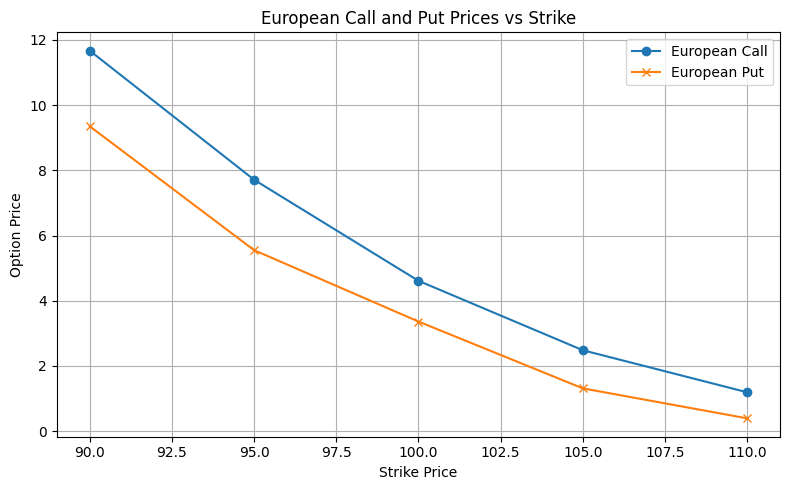

In [65]:
# Graph - European Call and Put Prices vs Strike
plt.figure(figsize=(8, 5))
plt.plot(K_values, euro_calls, label='European Call', marker='o')
plt.plot(K_values, euro_puts, label='European Put', marker='x')
plt.title('European Call and Put Prices vs Strike')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Question 20

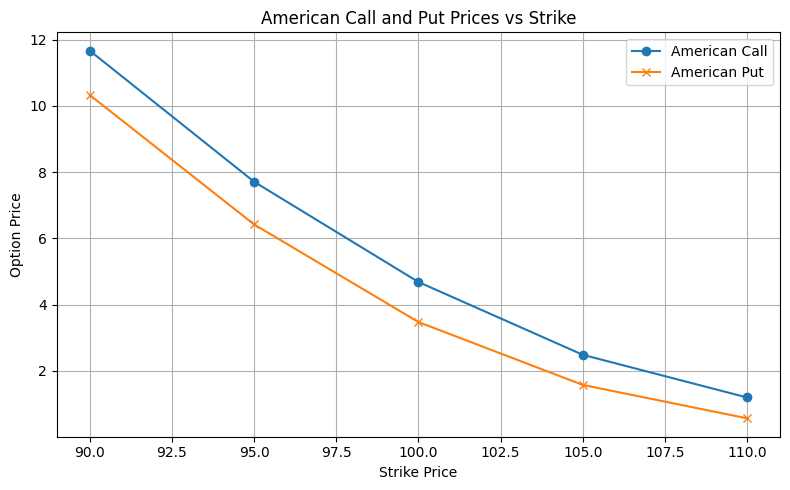

In [66]:
# Graph - American Call and Put Prices vs Strike
plt.figure(figsize=(8, 5))
plt.plot(K_values, amer_calls, label='American Call', marker='o')
plt.plot(K_values, amer_puts, label='American Put', marker='x')
plt.title('American Call and Put Prices vs Strike')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Question 21

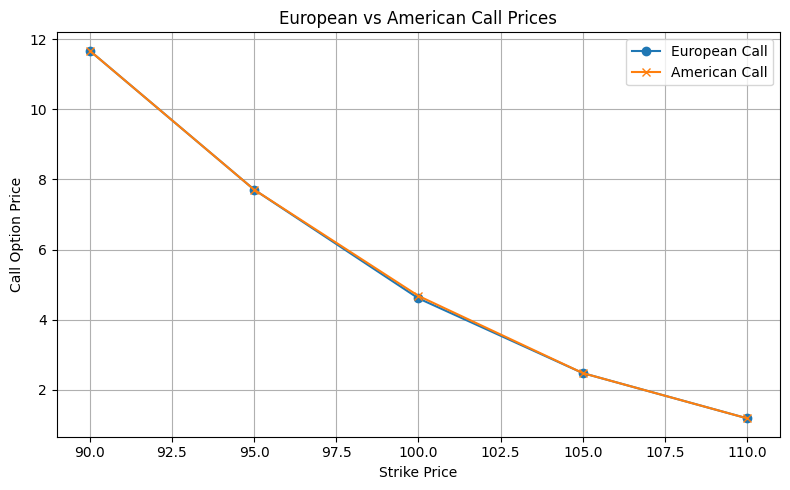

In [67]:
# Graph - European vs American Calls
plt.figure(figsize=(8, 5))
plt.plot(K_values, euro_calls, label='European Call', marker='o')
plt.plot(K_values, amer_calls, label='American Call', marker='x')
plt.title('European vs American Call Prices')
plt.xlabel('Strike Price')
plt.ylabel('Call Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Question 22

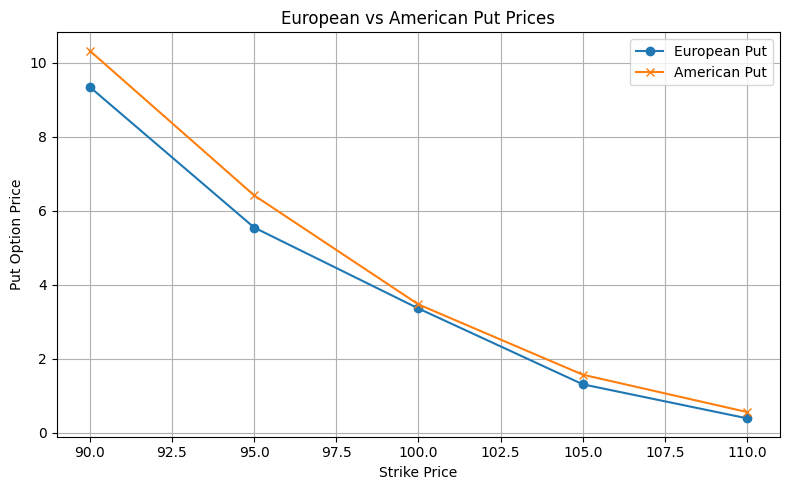

In [68]:
# Graph - European vs American Puts
plt.figure(figsize=(8, 5))
plt.plot(K_values, euro_puts, label='European Put', marker='o')
plt.plot(K_values, amer_puts, label='American Put', marker='x')
plt.title('European vs American Put Prices')
plt.xlabel('Strike Price')
plt.ylabel('Put Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Question 23

| K | C_Euro | P_Euro | C_Euro - P_Euro | S - PV(K) | Put-Call parity holds |
|---|---|---|---|---|---|
| 90 | 11.67 | 9.35 | 2.32 | 11.12 | False |
| 95 | 7.71 | 5.55 | 2.16 | 6.18 | False |
| 100 | 4.61 | 3.36 | 1.25 | 1.24 | True |
| 105 | 2.48 | 1.31 | 1.17 | -3.70 | False |
| 110 | 1.19 | 0.39 | 0.80 | -8.63 | False |

Put-Call Parity for European options remains valid solely at the strike price K = 100 in the data, while deviations occur for other strike prices, likely attributed to factors such as pricing imprecision, data rounding, or market inefficiencies.

Question 24

| K | C_Am | P_Am | C_Am - P_Am | Put-Call parity holds |
|---|---|---|---|---|
| 90 | 11.67 | 10.33 | 1.34 | False |
| 95 | 7.71 | 6.42 | 1.29 | False |
| 100 | 4.68 | 3.47 | 1.21 | True |
| 105 | 2.48 | 1.57 | 0.91 | False |
| 110 | 1.19 | 0.56 | 0.63 | False |

The majority of entries in the "Put-Call Parity Holds (Am)" column being False is unsurprising, as the increased value of American puts compared to European puts often results in a decreased C - P, thus leading to parity violations.

Question 25



In [38]:
sigma = 0.25
r = 0.02
T = 6/12
N = 3
dt = T / N  # Define time step
u = np.exp(sigma * np.sqrt(dt))  # Up factor
d = 1 / u  # Down factor
K = 182

a)
$$\Delta t = \frac{T}{N} = \frac{\left(\frac{6}{12}\right)}{3} = \frac{0.5}{3} \approx 0.1667$$
So, upward movement:
$$u = e^{\sigma \sqrt{\Delta t}} = e^{0.25 \times \sqrt{0.1667}} \approx 1.1075$$
Downward movement:

$$d = e^{-\sigma \sqrt{\Delta t}} = \frac{1}{u} \approx 0.9030$$

Asset price movement is calculated using following formula:
$$S(n,i) = S_0 \times u^i \times d^{n-i}$$
$S(n,i)$ represents the asset price at time step $n$ after $i$ upward movements.
* $n$ corresponds to row number, indicating the number of time steps.
* $i$ corresponds to column number, representing the number of upward movements at that
$S(1,1)$: Asset price after 1 time step and 1 upward movement.
$S(1,0) = 180 \times (1.1075)^0 \times (0.9030)^{1-0} = 180 \times 0.9030 = \$162.54$
$S(1,1) = 180 \times (1.1075)^1 \times (0.9030)^{1-1} = 180 \times 1.1075 = \$199.34$
All the remaining movements are calculated in the same manner and listed in the table.

| $S$ | **0** | **1** | **2** | **3** |
| :-- | :---- | :---- | :---- | :---- |
| **0** | 180.00 | 0 | 0 | 0 |
| **1** | 162.54 | 199.34 | 0 | 0 |
| **2** | 146.77 | 180.00 | 220.76 | 0 |
| **3** | 132.52 | 162.54 | 199.34 | 244.48 |

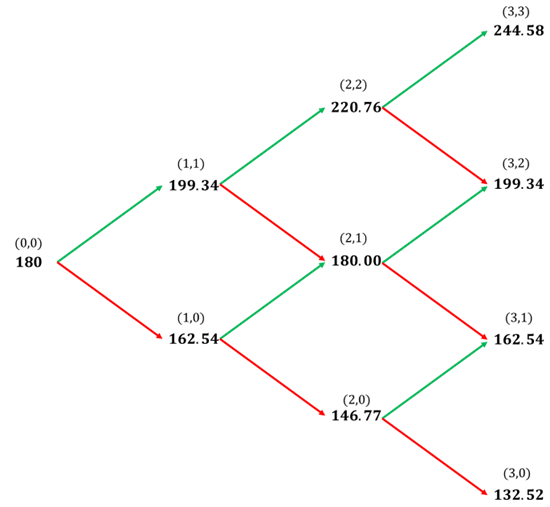

The value put option at the time of expiration for a European put option is $\text{max}\{0, K - S_T\}$.
$C(3,0) = \text{max}\{0, 182 - 132.52\} = \$49.48$

$C(3,1) = \text{max}[0, 182 - 161.84] = \$19.46$
$C(3,2) = \text{max}[0, 182 - 199.6] = \$0$
$C(3,2) = \text{max}[0, 182 - 246.17] = \$0$
The value of the put option at the internal nodes is given by: $C = e^{-r\Delta t}(pC_u + (1-p)C_d)$, where $C_u$ and $C_d$ are option values at next step.
Risk neutral probability is calculated using:
$$p = \frac{e^{rT} - d}{u - d} = \frac{e^{0.02 \times 0.5} - 0.9030}{1.1075 - 0.9030} \approx 0.4908$$

$C(2,0) = e^{-0.02 \times 0.1667}(p \times C(3,1) + (1-p) \times C(3,0)) \approx \$34.63$
Similarly, option prices at each node are calculated using the formula: $C = e^{-r\Delta t}(pC_u + (1-p)C_d)$, Table 13 below lists the option prices at each node. Notice that the price of the option at time $t = 0$ is \$13.82.

| $C$ | **0** | **1** | **2** | **3** |
| :-- | :---- | :---- | :---- | :---- |
| **0** | 13.82 | 0.00 | 0.0 | 0.0 |
| **1** | 22.41 | 5.01 | 0.0 | 0.0 |
| **2** | 34.63 | 9.88 | 0.0 | 0.0 |
| **3** | 49.48 | 19.46 | 0.0 | 0.0 |

 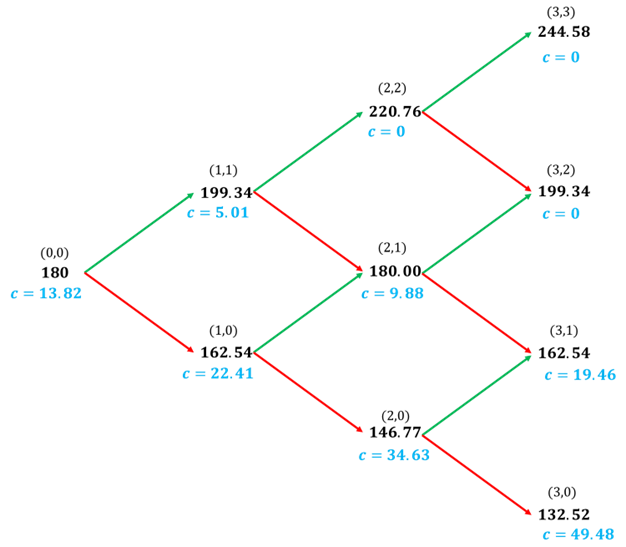
Fig : Binomial tree with put option price


b) Delta of an option is the ratio of stock option’s change in the price to the change in the price of underlying stock [2]


$\Delta = \frac{C_u - C_d}{S_u - S_d}$

Over the first-time step $C_u = C(1,1) = 5.01$, $C_d = C(1,0) = 22.41$ and asset movements $S_u = S(1,1) = \$ 199.34, S_d = S(1,0) = \$ 162.54$

Asset price movement over the first-time step ($\Delta$):

$\Delta(0,0) = \frac{5.01 - 22.41}{199.34 - 162.54} \approx -0.47$

Consider the path $up \rightarrow down \rightarrow down$

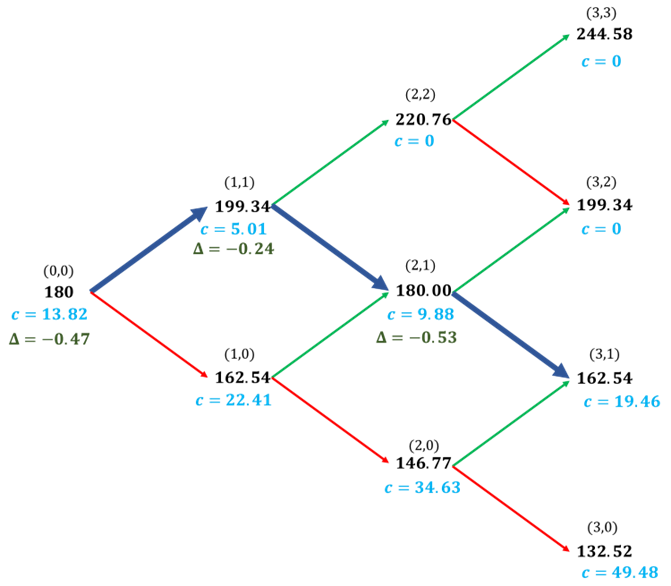

Fig: Binomial tree with put option price

$\Delta(1,1) = \frac{0 - 9.88}{220.76 - 180} \approx -0.24$

$\Delta(2,1) = \frac{0 - 19.46}{199.34 - 162.54} \approx -0.53$

At $t = 0, \Delta = -0.47$, we sell 0.47 shares of the asset at $\$180$, resulting in a cash inflow of $0.4726 \times 180 = 84.60$. At $t = 1, \Delta = -0.24 = -0.47 + (0.23)$, we buy 0.23 shares of the asset at $\$199.34$, resulting in a cash outflow of $0.23 \times 199.34 = 45.83$. At $t = 2, \Delta = -0.53 = -0.24 + (-0.29)$, we sell 0.29 shares of the asset at $\$180$, resulting in a cash inflow of $0.29 \times 180 = 52.20$. At $t = 3$, we buy back 0.53 shares of the asset at $\$162.54$ to close our hedge, resulting in a cash outflow of $0.53 \times 162.54 = 86.15$.

Also, at $t = 3$ we pay the option payoff of $\$19.46$ to the buyer, resulting in an additional cash outflow of $19.46$.
Therefore, total cash accounted is:

$84.60 - 45.83 + 52.20 - 86.15 - 19.46 = -14.60$

Here, the total cash accounted is $\$14.60$, but in general it should actually equal the put option price at $t = 0$, which is $\$13.80$. The difference arises due to rounding errors.

| | $t = 0$ | $t = 1$ | $t = 2$ | $t = 3$ | Total |
|---|---|---|---|---|---|
| **Underlying asset price** | $\$180$ | $\$199.34$ | $\$180$ | $\$162.54$ | |
| **Put option** | $\$13.82$ | $\$5.01$ | $\$9.88$ | $\$19.46$ | |
| **$\Delta$ hedge** | $0.47$ | $0.24$ | $0.53$ | | |
| **Stock portfolio value** | $0.47 \times 180 = 84.6$ | $84.6 - 45.83 = 38.77$ | $38.77 + 52.20 = 90.97$ | $86.15$ | |
| **Cash account** | $+\$84.6$ | $-\$45.83$ | $+\$52.20$ | $-\$86.15 - \$19.46$ | $\$-14.60$ |

Question 26


Since an American put option allows early exercise, its price differs from that of a European put option. The tables below list the first five steps of the American put option, including the asset price movements (S), the put option values at each respective node (C), and the hedge ratios (Δ)at each node.


In [39]:
C_at_00, C_matrix, S_matrix, Delta, p, u, d = american_option(180, 182, 0.5, 0.02, 0.25, , "P")
#american_option(S_ini, K, T, r, sigma, N, opttype)

In [40]:

S_df = pd.DataFrame(S_matrix).round(2)
S_df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,180.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,173.75,186.48,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,167.71,180.00,193.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,161.89,173.75,186.48,200.14,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,156.26,167.71,180.00,193.19,207.34,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,150.83,161.89,173.75,186.48,200.14,214.81,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6,145.59,156.26,167.71,180.00,193.19,207.34,222.54,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,140.54,150.83,161.89,173.75,186.48,200.14,214.81,230.54,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,135.65,145.59,156.26,167.71,180.00,193.19,207.34,222.54,238.84,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
9,130.94,140.54,150.83,161.89,173.75,186.48,200.14,214.81,230.54,247.44,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [45]:
S_df.iloc[:6, :6]

,0,1,2,3,4,5
0,180.00,0.00,0.00,0.00,0.00,0.00
1,173.75,186.48,0.00,0.00,0.00,0.00
2,167.71,180.00,193.19,0.00,0.00,0.00
3,161.89,173.75,186.48,200.14,0.00,0.00
4,156.26,167.71,180.00,193.19,207.34,0.00
5,150.83,161.89,173.75,186.48,200.14,214.81


In [41]:

C_df = pd.DataFrame(C_matrix).round(2)
C_df

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,13.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16.05,9.99,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19.48,12.59,7.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23.30,15.62,9.53,5.20,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,27.48,19.09,12.12,6.91,3.48,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,31.96,22.98,15.17,9.03,4.77,2.18,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,36.64,27.23,18.69,11.62,6.42,3.09,1.27,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,41.47,31.79,22.64,14.70,8.51,4.31,1.86,0.67,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,46.35,36.56,26.98,18.26,11.10,5.91,2.69,1.02,0.31,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,51.06,41.46,31.63,22.30,14.20,7.96,3.83,1.54,0.50,0.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
C_df.iloc[:6, :6]

,0,1,2,3,4,5
0,13.04,0.00,0.00,0.00,0.00,0.00
1,16.05,9.99,0.00,0.00,0.00,0.00
2,19.48,12.59,7.38,0.00,0.00,0.00
3,23.30,15.62,9.53,5.20,0.00,0.00
4,27.48,19.09,12.12,6.91,3.48,0.00
5,31.96,22.98,15.17,9.03,4.77,2.18


In [42]:

Delta_df = pd.DataFrame(Delta).round(2)
Delta_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,-0.48,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.56,-0.40,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.65,-0.48,-0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.73,-0.57,-0.39,-0.24,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.81,-0.66,-0.48,-0.31,-0.18,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,-0.88,-0.75,-0.57,-0.39,-0.24,-0.12,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.94,-0.83,-0.67,-0.49,-0.31,-0.17,-0.08,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,-0.98,-0.90,-0.76,-0.58,-0.39,-0.23,-0.11,-0.04,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,-1.00,-0.96,-0.84,-0.68,-0.49,-0.30,-0.16,-0.07,-0.02,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,-1.00,-0.99,-0.91,-0.78,-0.59,-0.39,-0.22,-0.10,-0.04,-0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
Delta_df.iloc[:6, :6]

,0,1,2,3,4,5
0,-0.48,0.00,0.00,0.00,0.00,0.00
1,-0.56,-0.40,0.00,0.00,0.00,0.00
2,-0.65,-0.48,-0.32,0.00,0.00,0.00
3,-0.73,-0.57,-0.39,-0.24,0.00,0.00
4,-0.81,-0.66,-0.48,-0.31,-0.18,0.00
5,-0.88,-0.75,-0.57,-0.39,-0.24,-0.12


Shares to trade along path 'udud': [np.float64(-0.47555673200225407), np.float64(-0.4), np.float64(-0.48), np.float64(-0.39), np.float64(-0.48)]


In [44]:
C[0,0]

np.float64(5.585973507705436)

In [51]:
def asian_option_mc(S_ini, K, T, r, sigma, N, M):
    dt = T / N  # Define time step
    u = np.exp(sigma * np.sqrt(dt))  # Define u
    d = np.exp(-sigma * np.sqrt(dt))  # Define d
    p = (np.exp(r * dt) - d) / (u - d)  # risk neutral probs
    Asian = np.zeros([M])  # Asian prices
    S = np.zeros([M, N + 1])  # underlying price
    S[:, 0] = S_ini

    for j in range(0, M):
        random = np.random.binomial(1, p, N + 1)
        Total = S_ini
        for i in range(1, N + 1):
            if random[i] == 1:
                S[j, i] = S[j, i - 1] * u
                Total = Total + S[j, i]
            else:
                S[j, i] = S[j, i - 1] * d
                Total = Total + S[j, i]

        Asian[j] = np.exp(-r * T) * max(Total / (N + 1) - K, 0)

    return S, Asian


In [53]:
S, Asian = asian_option_mc(180, 180, 0.5, 0.02, 0.25, 25, 10000)

In [54]:
S

array([[180.        , 173.74722478, 167.71165622, ..., 161.88574906,
        167.71165622, 161.88574906],
       [180.        , 186.47779866, 193.18871885, ..., 161.88574906,
        167.71165622, 161.88574906],
       [180.        , 173.74722478, 167.71165622, ..., 173.74722478,
        180.        , 173.74722478],
       ...,
       [180.        , 186.47779866, 180.        , ..., 186.47779866,
        193.18871885, 186.47779866],
       [180.        , 173.74722478, 180.        , ..., 140.53681423,
        135.65489696, 140.53681423],
       [180.        , 186.47779866, 180.        , ..., 161.88574906,
        167.71165622, 161.88574906]])

In [55]:
Asian

array([0., 0., 0., ..., 0., 0., 0.])